In [ ]:
import yaml
import pickle as pkl
import matplotlib.pyplot as plt

import torch

from train_utils import utils
from dataset_utils.synthetic_utils import plot_trajectories

/projectnb/biochemai/Grant/interaction_rule_GNN/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# get the predictions and the ground truth
ground_truth = pkl.load(open('../data/spring_mass/static_graph/graphs/trial_0.pkl', 'rb'))

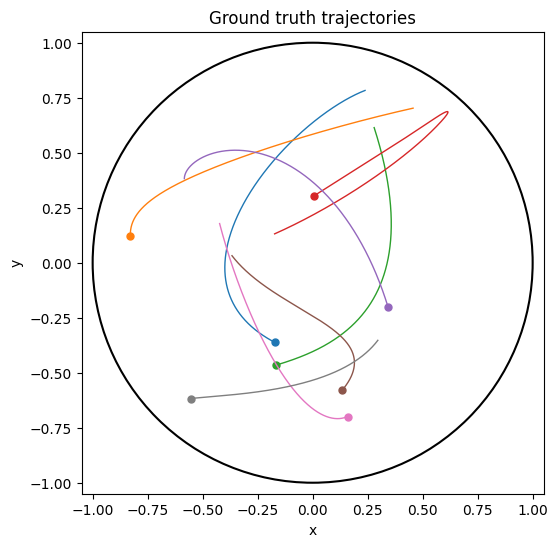

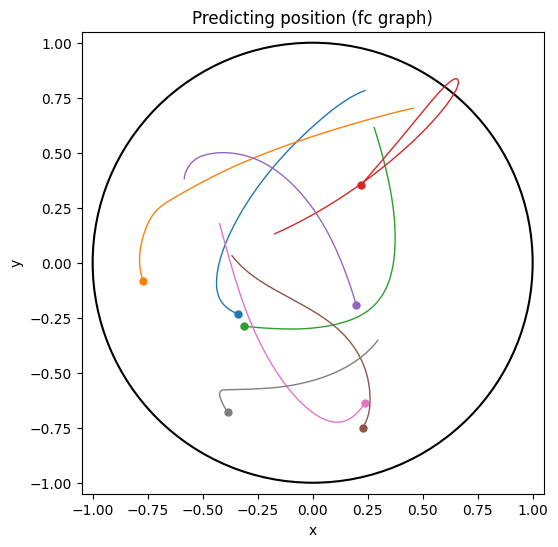

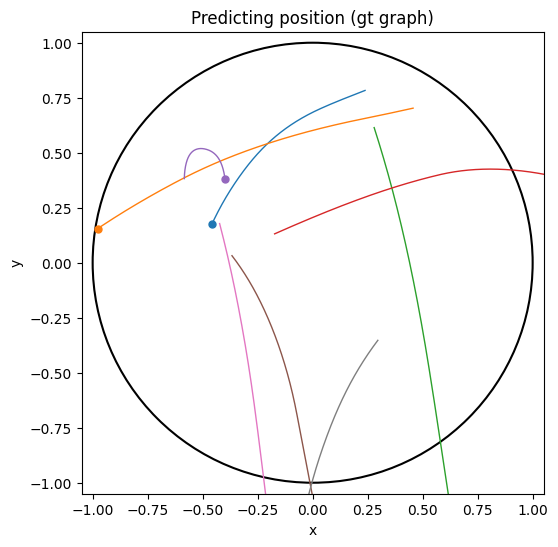

In [ ]:
# split data up into train
config = yaml.safe_load(open('../results/SpringMass/GAT/model/pred_acc_no_edges_self_loops/trial_0_config.yaml', 'r'))
dat_train, dat_val, dat_test = utils.split_with_config(ground_truth, config)

# plotting ground truth
gt_pos = torch.stack([i.pos for i in dat_test])
ax = plot_trajectories(gt_pos.permute(2, 1, 0))
ax.set_title('Ground truth trajectories')

# Plotting predictions
preds = pkl.load(open('../_dt_sweep_experiment/results/model/dt16/trial_0_rollout_preds.pkl', 'rb'))
ax = plot_trajectories(torch.stack(preds).permute(2, 1, 0))
ax.set_title("16dt")

preds = pkl.load(open('../_dt_sweep_experiment/results/model/dt128/trial_0_rollout_preds.pkl', 'rb'))
ax = plot_trajectories(torch.stack(preds).permute(2, 1, 0))
ax.set_title("128dt")

plt.show()

In [ ]:
import os
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

tb_fp = '../interaction_rule_GNN/_dt_sweep_experiment/results/logs'

# plotting rollout loss over time for different models
data = {
    'time_step': [],
    'split': [],
    'loss': []
}

# loop through tensorboard events and pull out important data
for time_step in os.listdir(tb_fp):
    for split in os.listdir(os.path.join(tb_fp, time_step)):
        for event in os.listdir(os.path.join(tb_fp, time_step, split)):
            event_acc = EventAccumulator(os.path.join(tb_fp, time_step, split, event))
            event_acc.Reload()
            val = event_acc.Scalars('one_step/avg_loss')[0].value
            data['time_step'].append(time_step)
            data['split'].append(split)
            data['loss'].append(val)